In [ ]:
!pip install ssam

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.6/244.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 18.7 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=17cc3ead03471ddce97916f4abafc443585bab84b56fb018113746e8e384e92a
  Stored in directory: /root/.cache/pip/wheels/71/c1/da/23077eb3b87d24d6f3852ed1ed1a1ac2d3c885ad6ebd2b4a07
Successfully built asciitree


In [ ]:
!wget https://s3.amazonaws.com/starfish.data.spacetx/spacetx-website/data/smFISH_Allen/s3_cell_by_gene.csv

--2025-06-01 11:48:38--  https://s3.amazonaws.com/starfish.data.spacetx/spacetx-website/data/smFISH_Allen/s3_cell_by_gene.csv
Resolving s3.amazonaws.com (s3.amazonaws.com)... 54.231.163.176, 54.231.202.208, 52.216.221.80, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|54.231.163.176|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 129436 (126K) [text/csv]
Saving to: ‘s3_cell_by_gene.csv’

s3_cell_by_gene.csv 100%[===================>] 126.40K  --.-KB/s    in 0.05s   

2025-06-01 11:48:38 (2.27 MB/s) - ‘s3_cell_by_gene.csv’ saved [129436/129436]



In [ ]:
!wget https://s3.amazonaws.com/starfish.data.spacetx/spacetx-website/data/smFISH_Allen/s3_spot_table.csv

--2025-06-01 11:48:38--  https://s3.amazonaws.com/starfish.data.spacetx/spacetx-website/data/smFISH_Allen/s3_spot_table.csv
Resolving s3.amazonaws.com (s3.amazonaws.com)... 54.231.163.176, 54.231.202.208, 52.216.221.80, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|54.231.163.176|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 55124358 (53M) [text/csv]
Saving to: ‘s3_spot_table.csv’

s3_spot_table.csv   100%[===================>]  52.57M  76.3MB/s    in 0.7s    

2025-06-01 11:48:39 (76.3 MB/s) - ‘s3_spot_table.csv’ saved [55124358/55124358]



In [ ]:
import ssam

In [ ]:
ds = ssam.SSAMDataset("exampledata")
analysis = ssam.SSAMAnalysis(ds, verbose=True)

In [ ]:
import pandas as pd

In [ ]:
spots = pd.read_csv("s3_spot_table.csv")

In [ ]:
spots

,Unnamed: 0,gene,molecule_id,confidence,cell,assignment_confidence,rotated_x,rotated_y,xc,yc
0,0,Fezf2,4,1.00000,1605,1.0,1296.718027,813.958480,1296.718027,813.958480
1,1,Fezf2,17,1.00000,2496,1.0,1302.424423,844.131209,1302.424423,844.131209
2,2,Fezf2,36,1.00000,1605,1.0,1293.752097,822.910508,1293.752097,822.910508
3,3,Fezf2,77,0.99999,1605,1.0,1292.981468,825.102131,1292.981468,825.102131
4,4,Fezf2,86,1.00000,3929,1.0,1254.284721,915.218969,1254.284721,915.218969
...,...,...,...,...,...,...,...,...,...,...
530778,530778,Parm1,1071304,0.99995,407,1.0,115.997457,502.193148,115.997457,502.193148
530779,530779,Parm1,1071313,1.00000,4354,1.0,134.008161,429.477827,134.008161,429.477827
530780,530780,Parm1,1071319,0.99972,3478,1.0,107.807802,398.245527,107.807802,398.245527
530781,530781,Parm1,1071321,0.99999,999,1.0,120.079417,451.938345,120.079417,451.938345


In [ ]:
spots_xy = spots.rename(columns={'rotated_x': 'x', 'rotated_y': 'y'})[['gene', 'x', 'y']]
spots_xy

,gene,x,y
0,Fezf2,1296.718027,813.958480
1,Fezf2,1302.424423,844.131209
2,Fezf2,1293.752097,822.910508
3,Fezf2,1292.981468,825.102131
4,Fezf2,1254.284721,915.218969
...,...,...,...
530778,Parm1,115.997457,502.193148
530779,Parm1,134.008161,429.477827
530780,Parm1,107.807802,398.245527
530781,Parm1,120.079417,451.938345


In [ ]:
analysis.run_kde(spots_xy, width=1330, height=1220)

Saving KDE for gene Thsd7a: 100%|██████████| 22/22 [01:17<00:00,  3.51s/it]


Done!


In [ ]:
analysis.find_localmax()

Finding local maxima...
Filtering local maxima based on norm threshold...
Filtering local maxima based on gene expression threshold...
Found 2787 local max vectors.


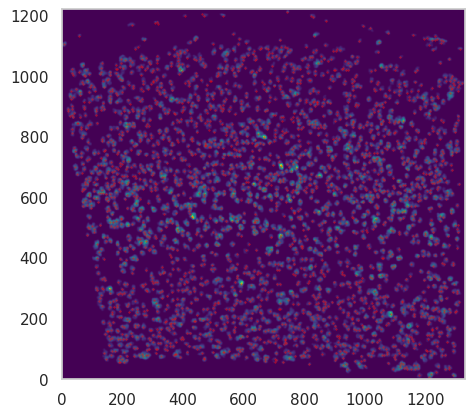

In [ ]:
ds.plot_l1norm()
ds.plot_localmax(s=0.1, c='red')

In [ ]:
analysis.normalize_vectors()
analysis.scale_vectors()

Normalizing local maxima vectors...
Normalizing vector field...


100%|██████████| 1/1 [00:02<00:00,  2.68s/it]

Scaling data...



100%|██████████| 1/1 [00:01<00:00,  1.37s/it]


In [ ]:
analysis.cluster_vectors()

Found 15 clusters


In [ ]:
ds.run_umap()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


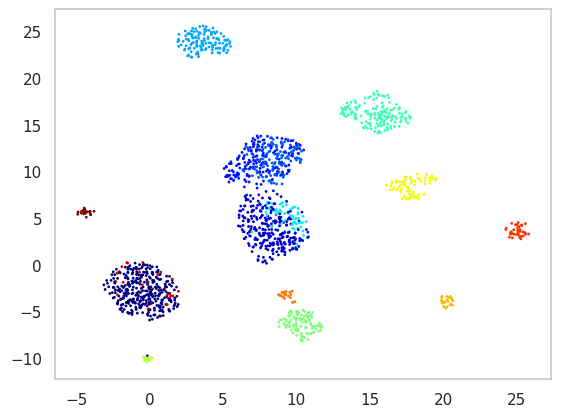

In [ ]:
ds.plot_umap(s=1)

In [ ]:
analysis.map_celltypes()

Centroid: 100%|██████████| 15/15 [00:10<00:00,  1.48it/s]


In [ ]:
analysis.filter_celltypemaps()

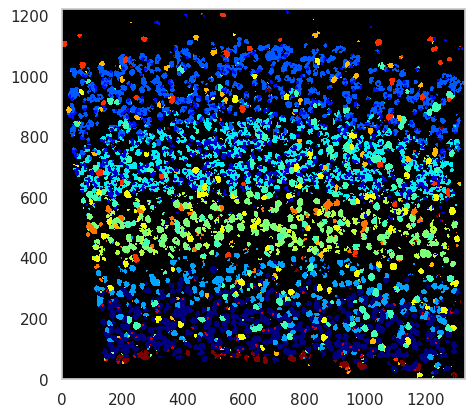

In [ ]:
ds.plot_celltypes_map()

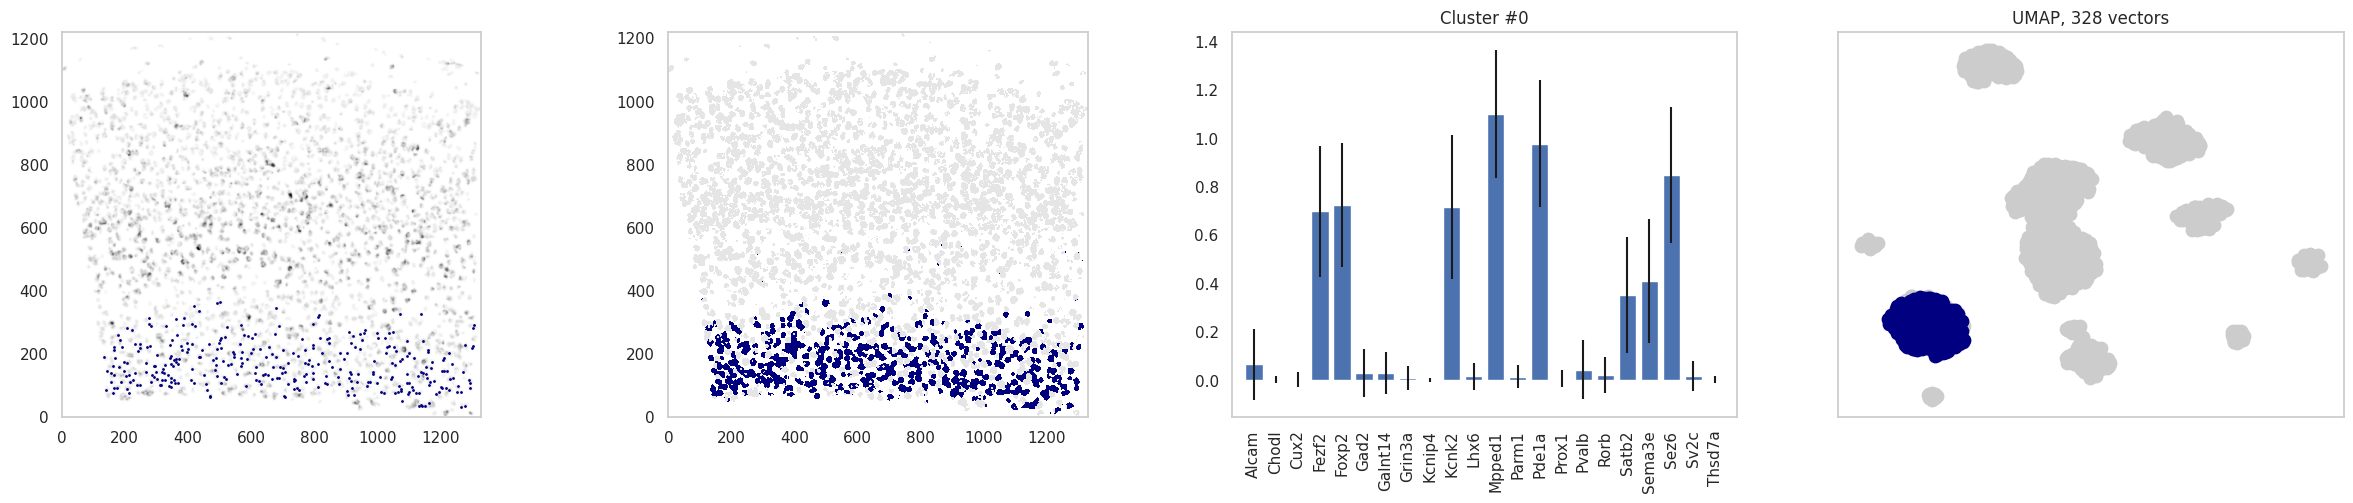

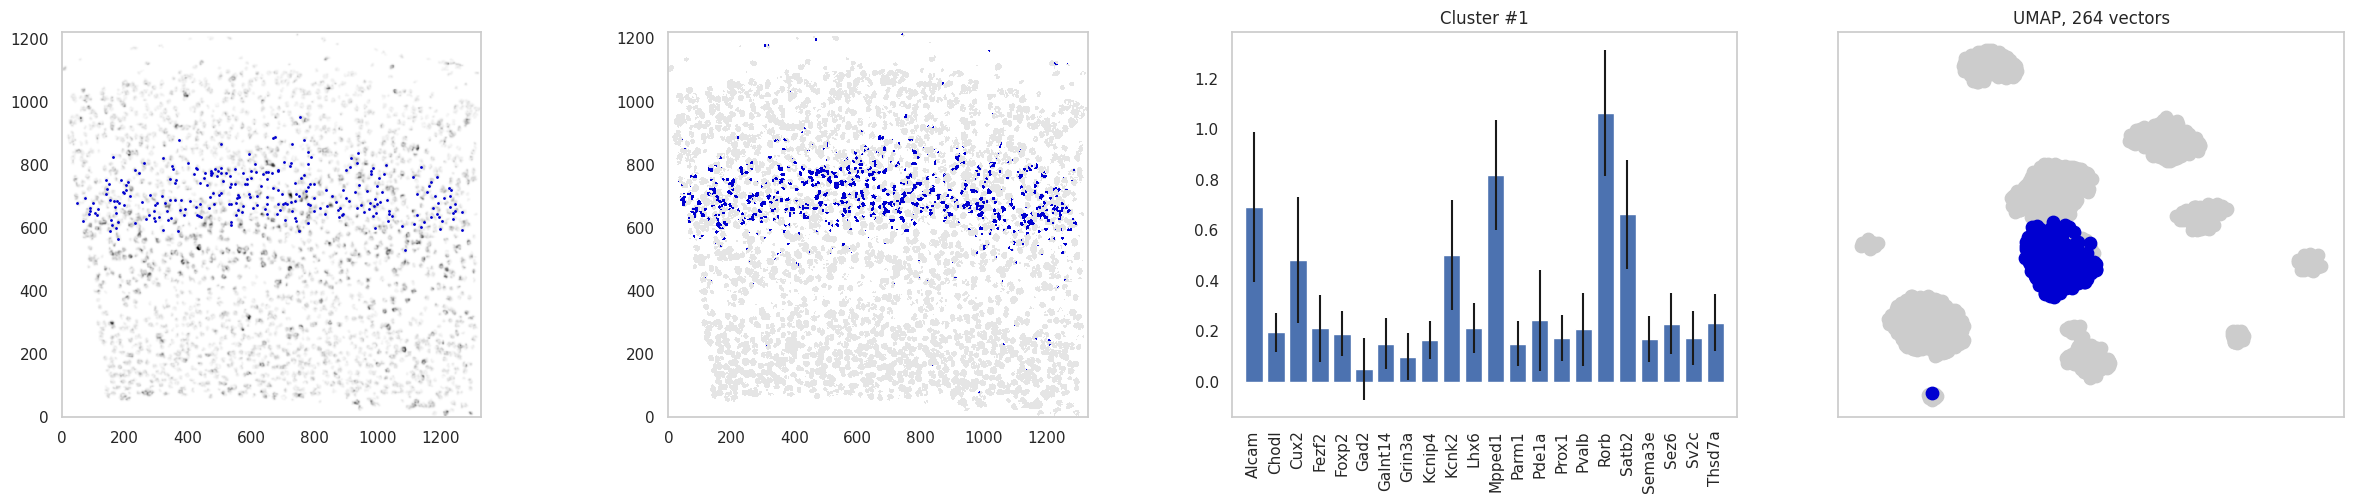

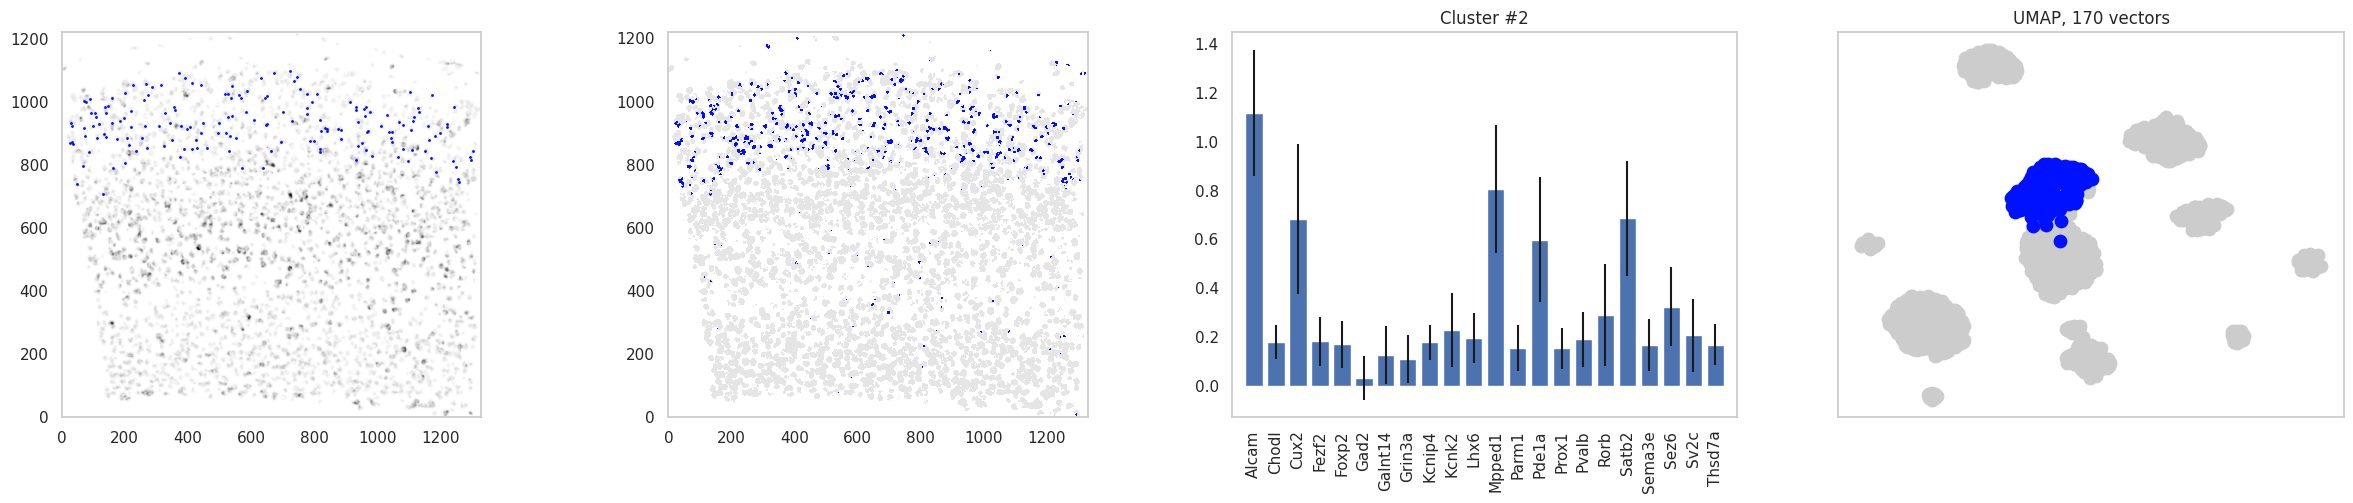

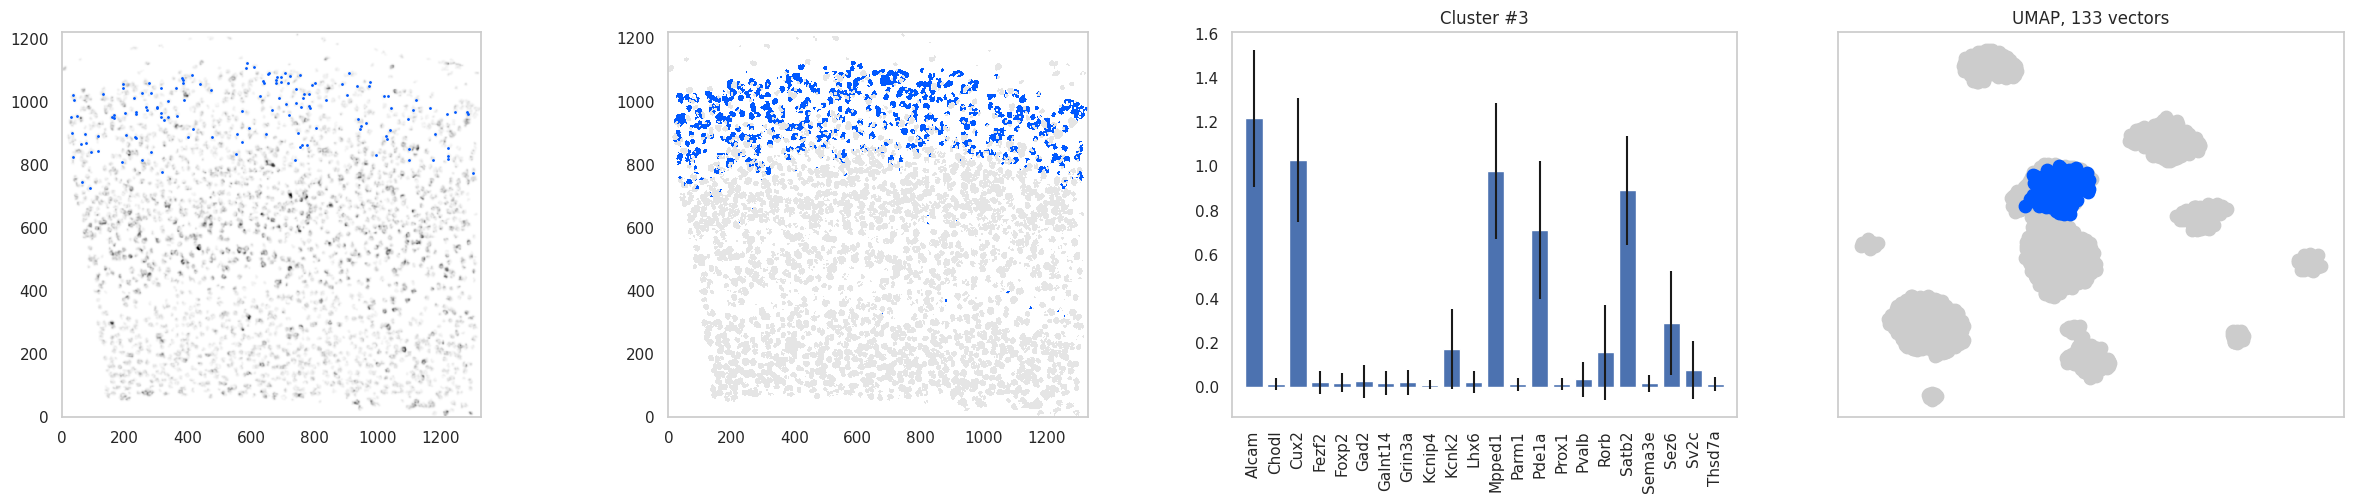

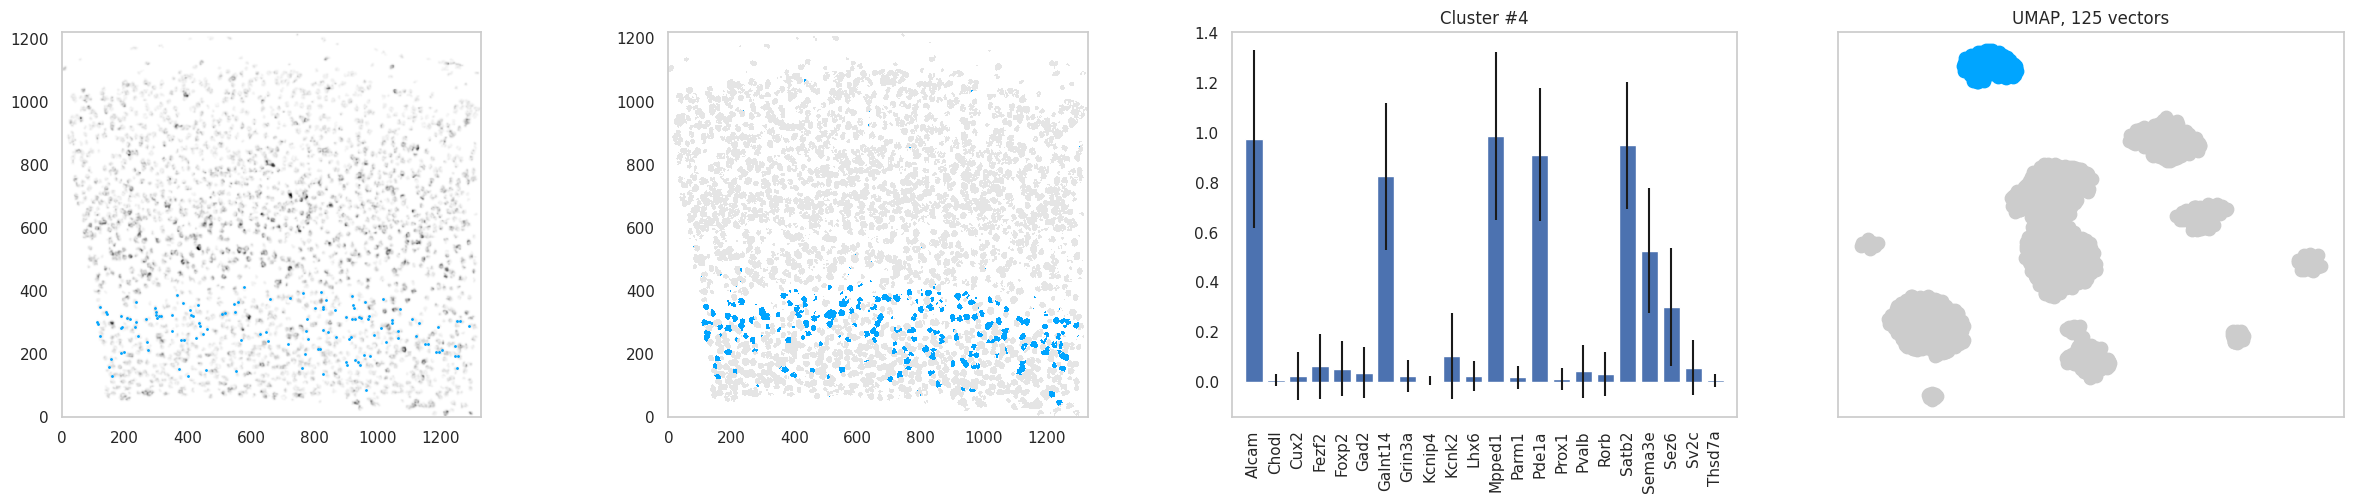

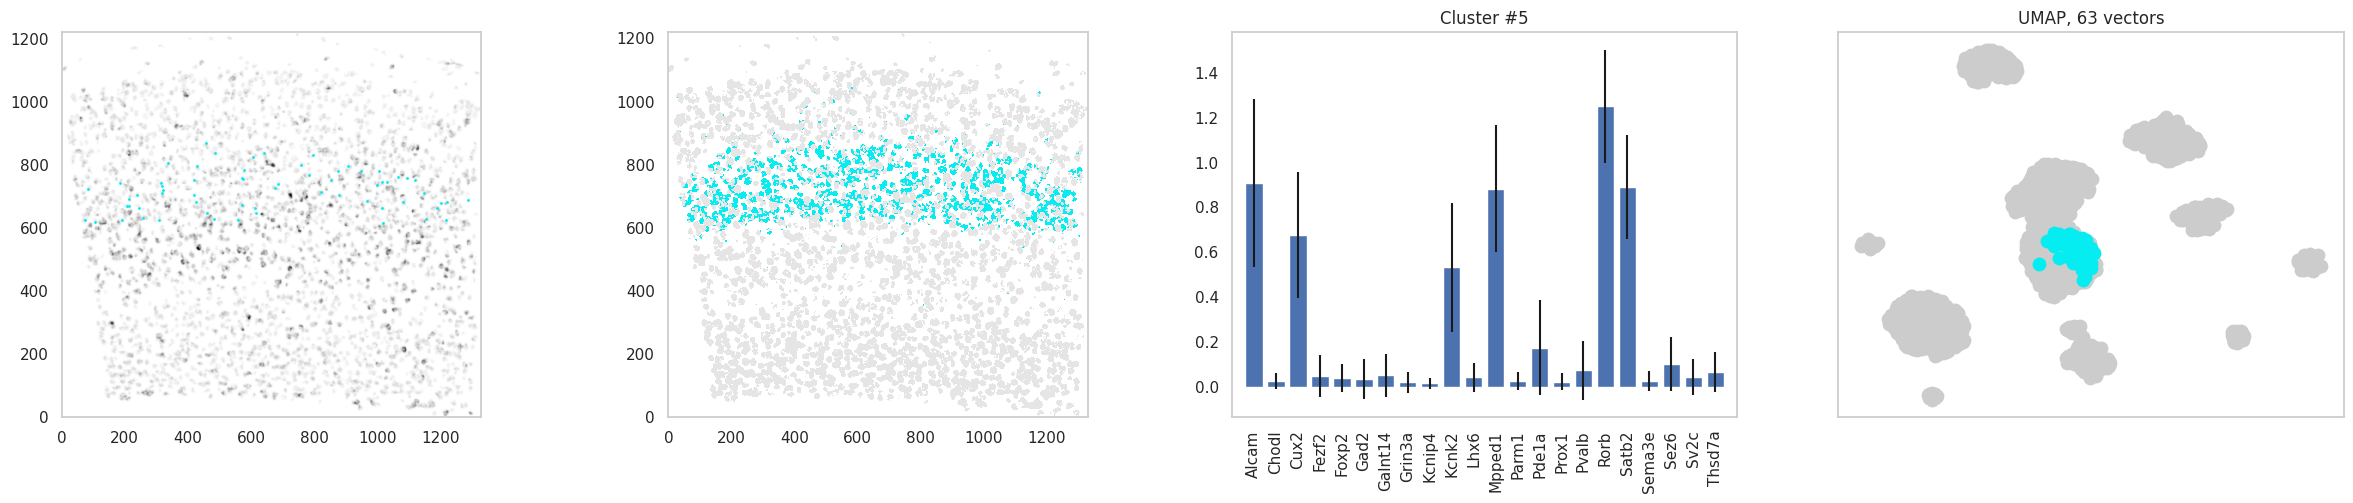

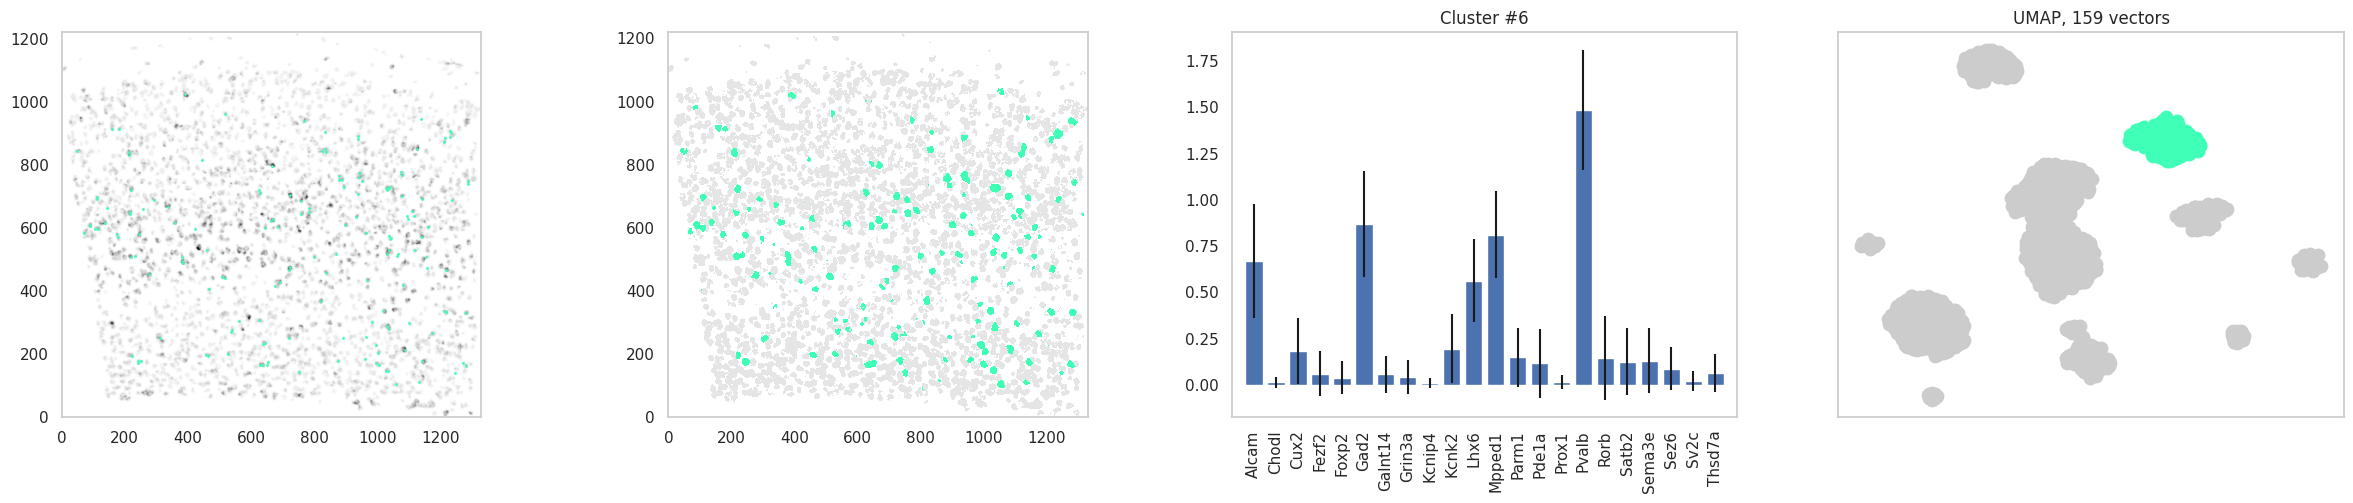

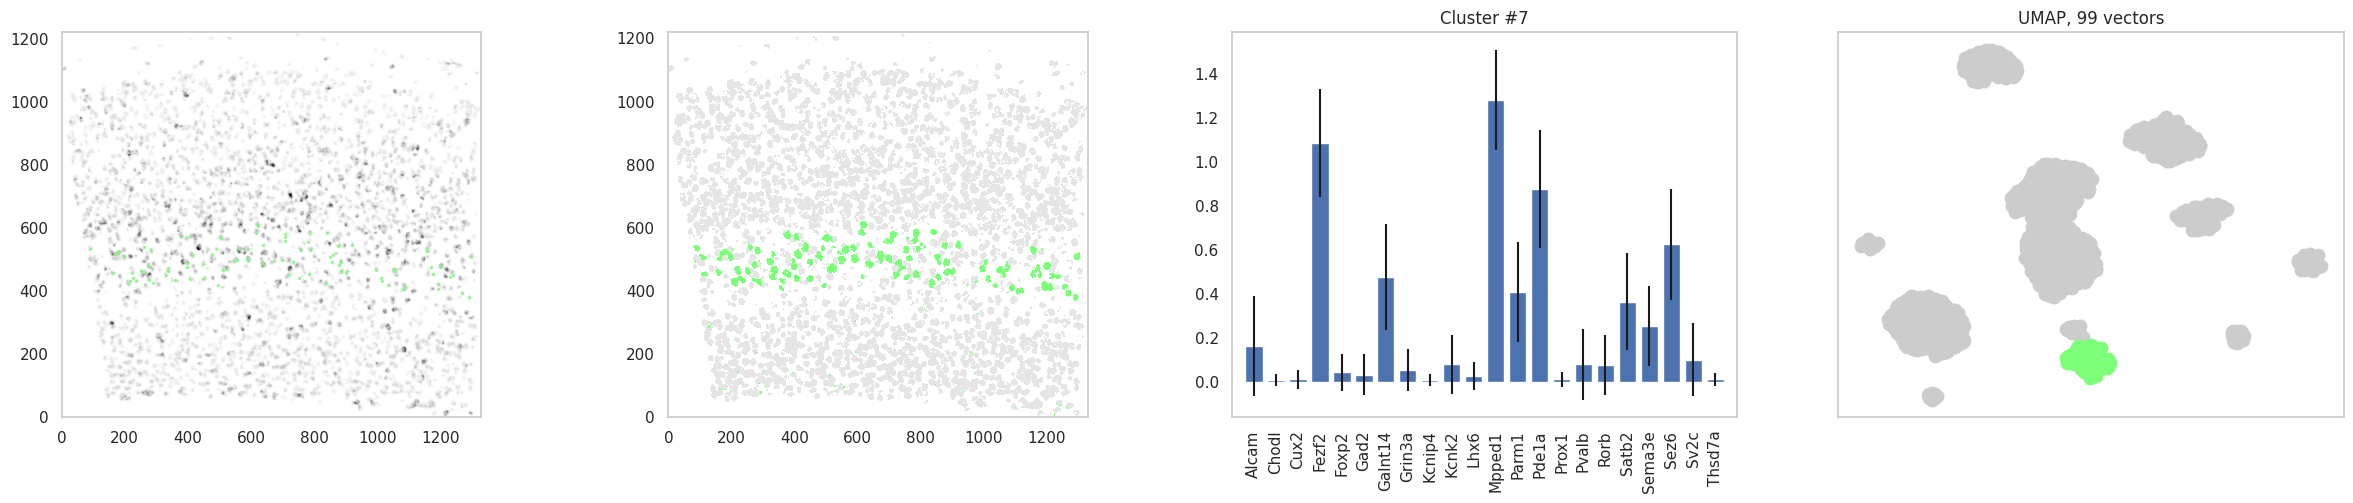

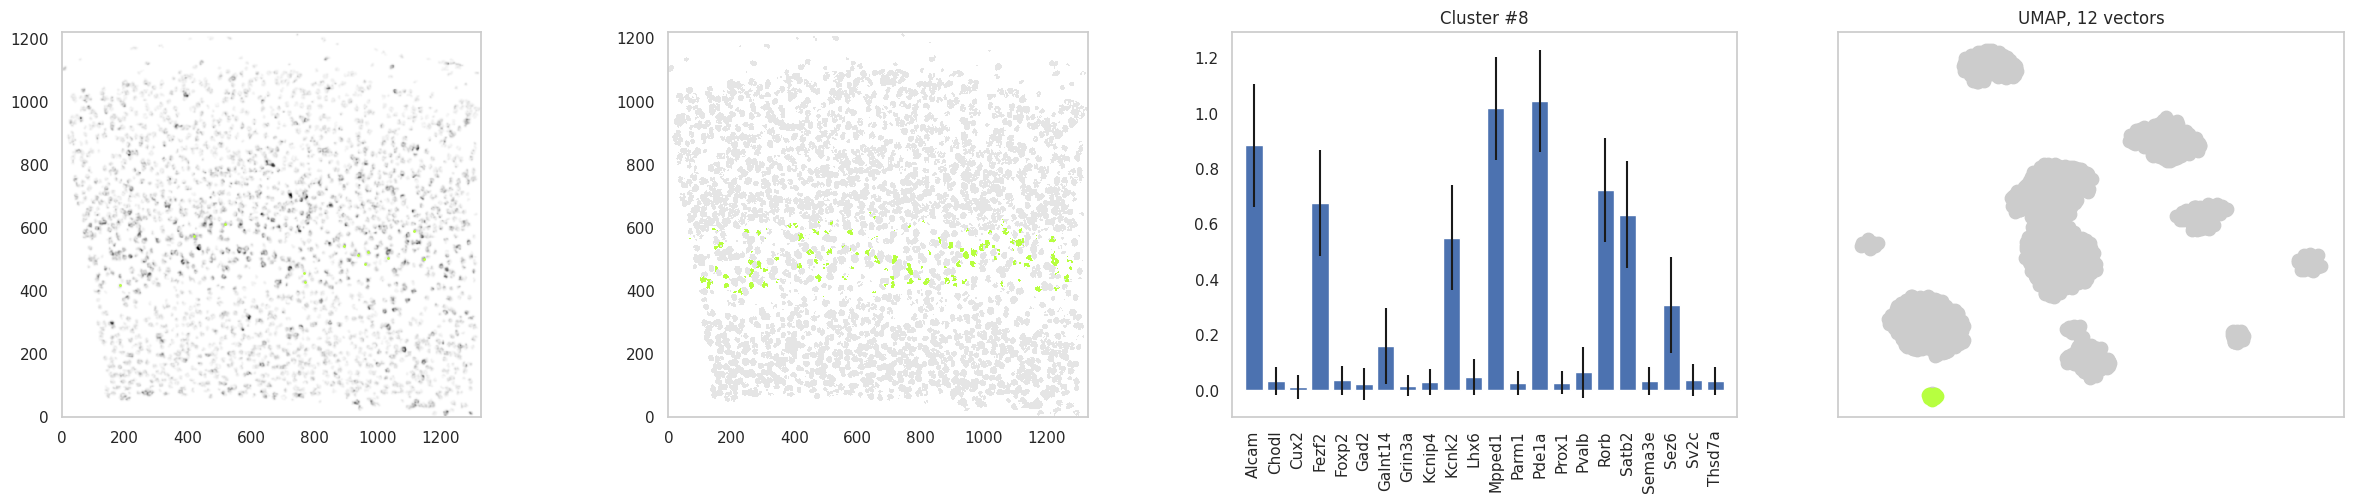

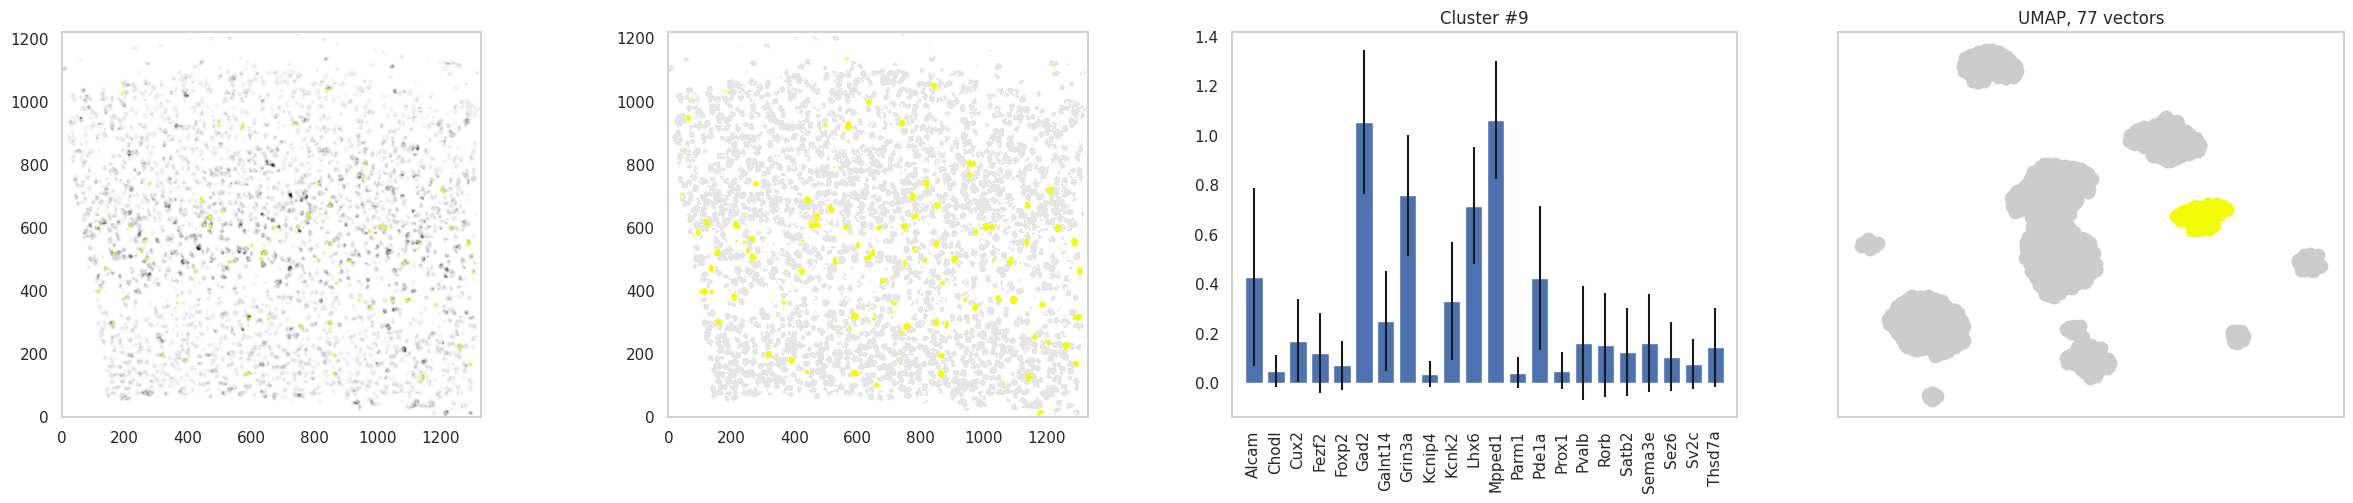

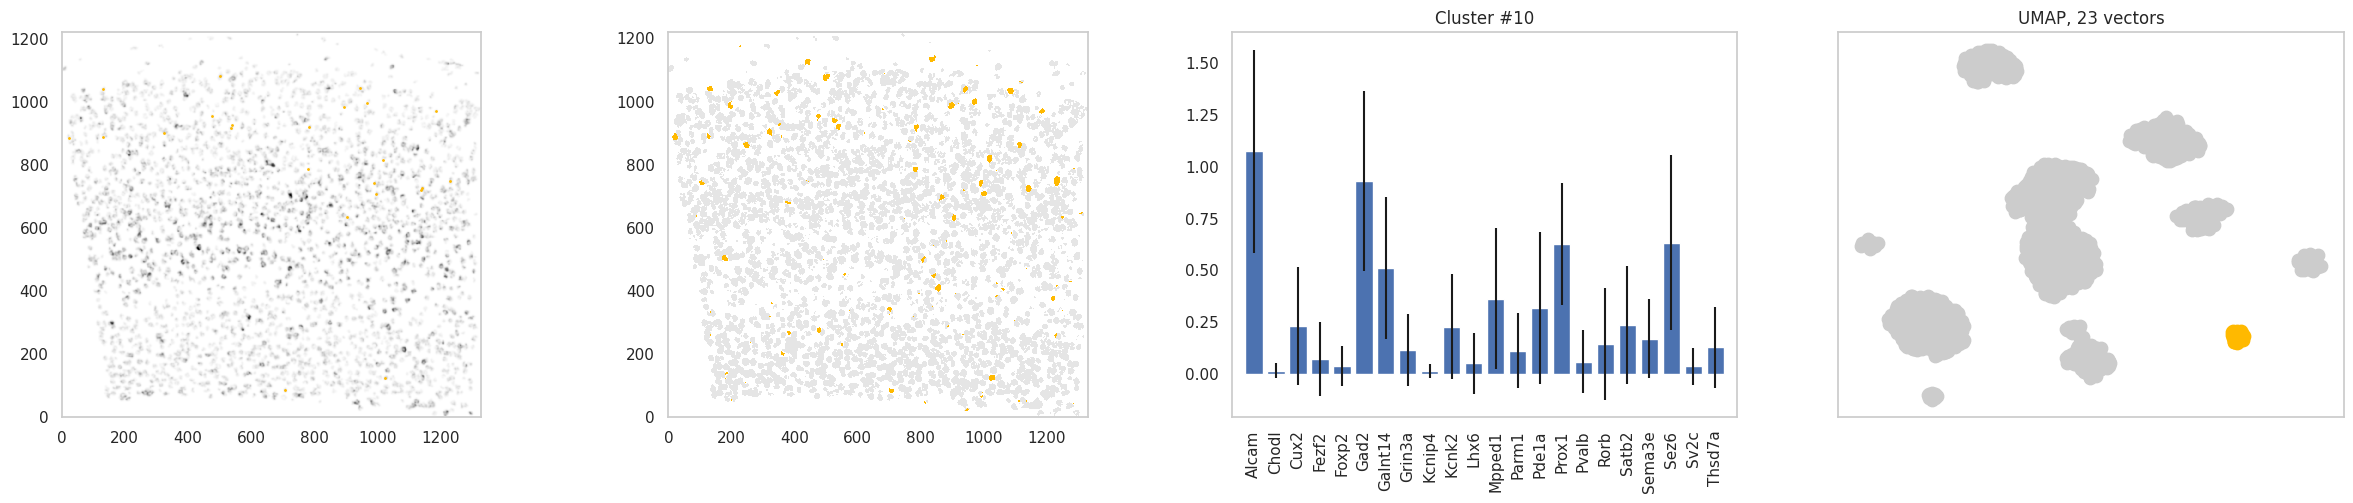

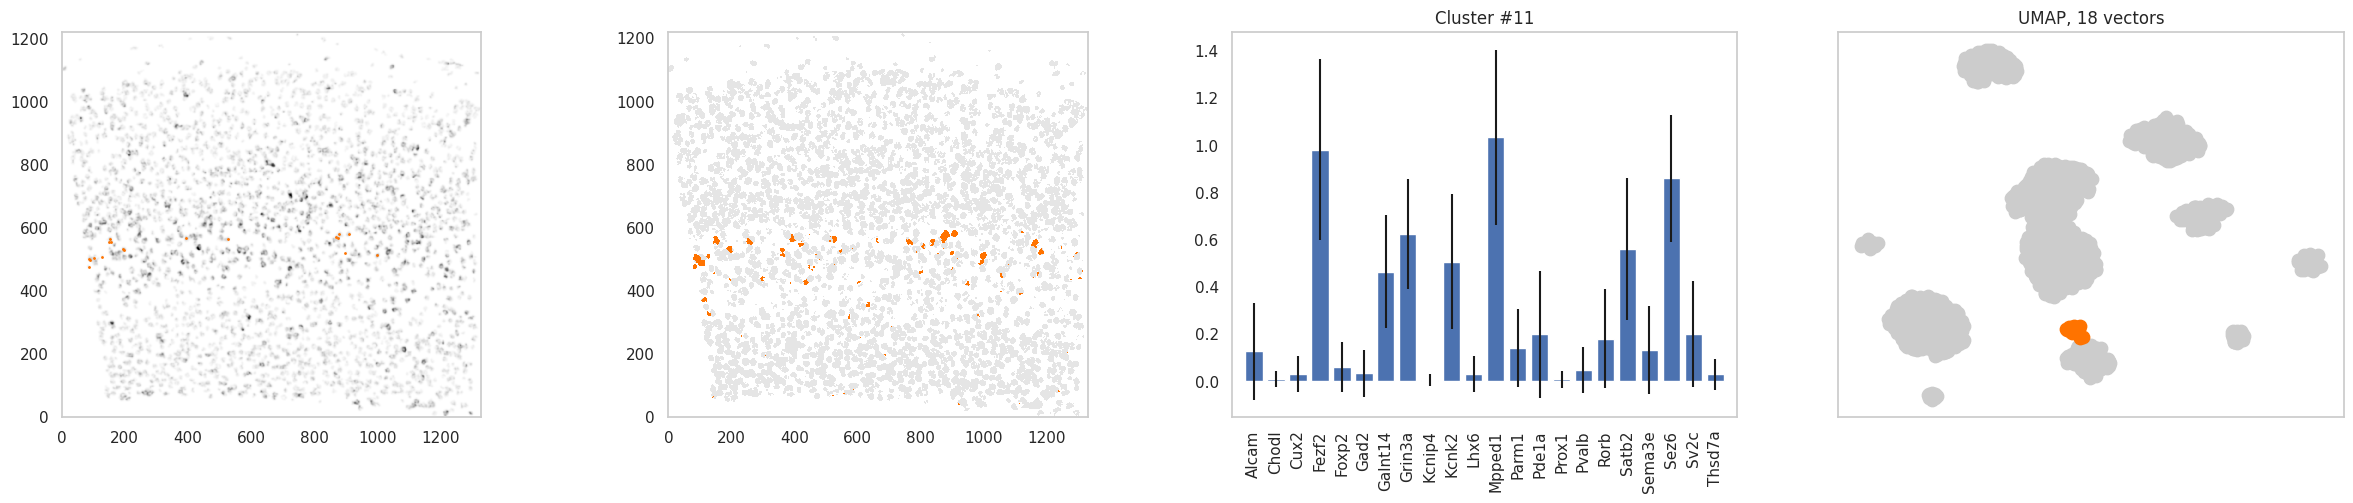

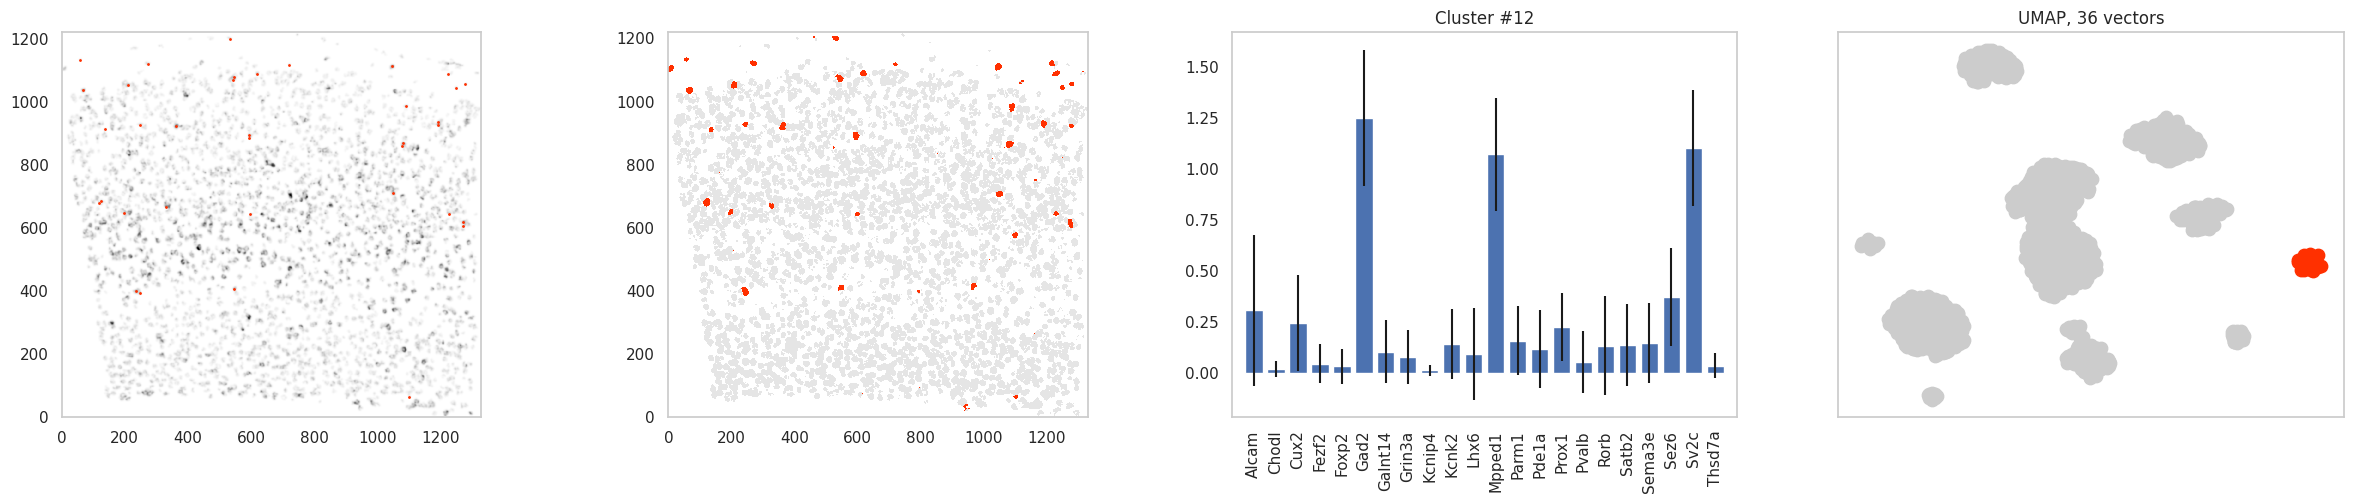

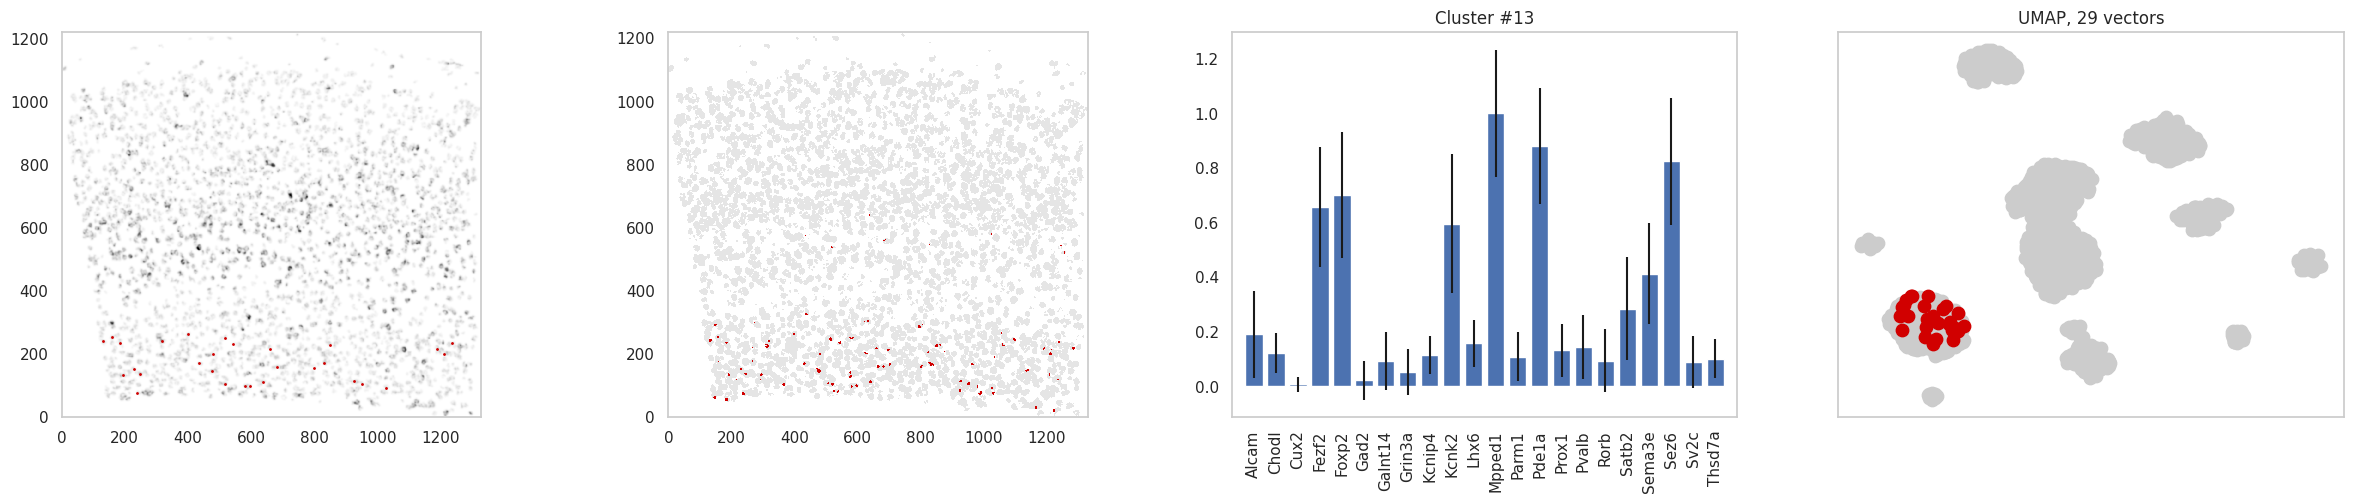

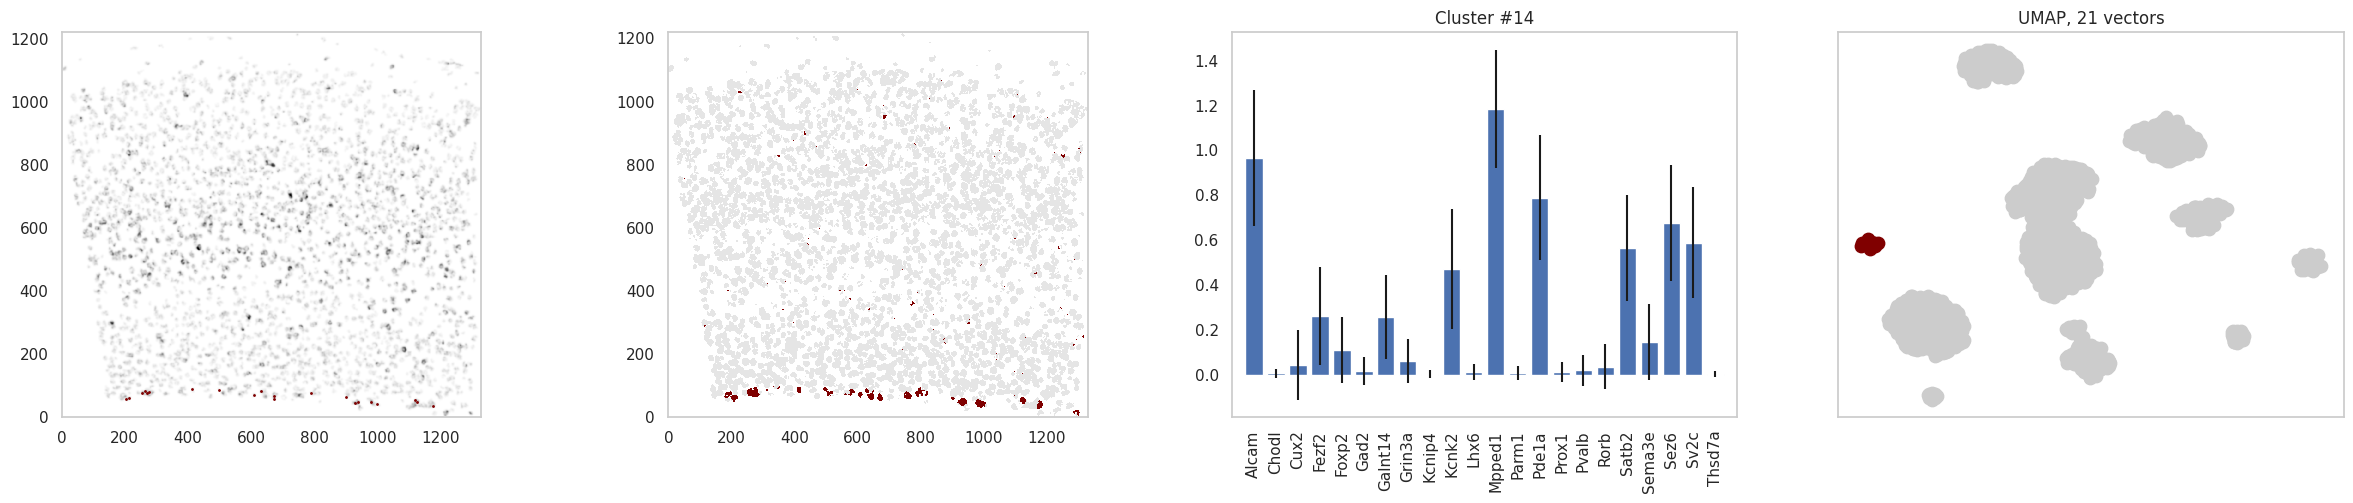

In [ ]:
import matplotlib.pyplot as plt

for i in range(15): # number of cell types
  plt.figure(figsize=[30,5]) # make it wide
  ds.plot_diagnostic_plot(i, use_embedding='umap')

In [ ]:
import pandas as pd
cxg = pd.read_csv("s3_cell_by_gene.csv", header=1, index_col='gene_name')[ds.genes]
cxg

,Alcam,Chodl,Cux2,Fezf2,Foxp2,Gad2,Galnt14,Grin3a,Kcnip4,Kcnk2,...,Parm1,Pde1a,Prox1,Pvalb,Rorb,Satb2,Sema3e,Sez6,Sv2c,Thsd7a
gene_name,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,15,20,0,0,1,0,30,...,0,16,0,1,0,9,4,12,0,0
5,4,1,20,3,1,3,2,0,1,39,...,1,10,2,3,52,32,2,6,1,2
6,36,1,39,1,1,0,1,0,2,3,...,0,6,1,1,2,24,1,6,1,1
7,32,1,37,2,1,0,0,1,1,8,...,2,20,1,2,2,18,2,7,0,1
9,66,0,19,2,0,75,0,0,0,6,...,6,1,0,255,7,1,1,3,0,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4664,19,1,42,2,2,1,0,0,1,3,...,1,32,1,0,2,13,0,19,0,2
4665,0,0,0,15,21,1,0,0,0,32,...,0,39,0,3,0,11,15,28,0,0
4669,57,10,6,9,5,65,23,50,4,18,...,6,4,4,6,2,4,20,8,7,6


In [ ]:
!pip install scanpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 3.8 MB/s eta 0:00:00


In [ ]:
import scanpy as sc # This requires `pip install scanpy`

In [ ]:
adata = sc.AnnData(cxg)

/usr/local/lib/python3.11/dist-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [ ]:
# A standard scRNA-seq processing pipeline
# e.g., https://scanpy-tutorials.readthedocs.io/en/latest/pbmc3k.html
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10)
sc.tl.leiden(adata, resolution=0.6)

<ipython-input-25-2866309dbc7d>:7: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.6)


In [ ]:
sc.tl.umap(adata)

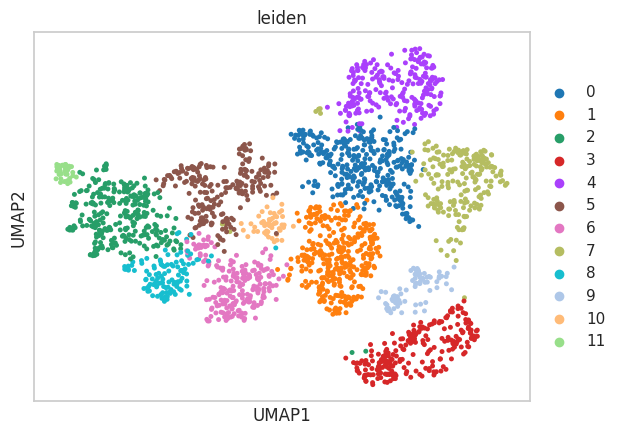

In [ ]:
sc.pl.umap(adata, color='leiden')

In [ ]:
centroids = []
for cl in adata.obs.leiden.unique():
  centroids.append(adata.X[adata.obs.leiden == cl].mean(axis=0))

In [ ]:
analysis.map_celltypes(centroids)

Centroid: 100%|██████████| 12/12 [00:15<00:00,  1.26s/it]


In [ ]:
analysis.filter_celltypemaps()

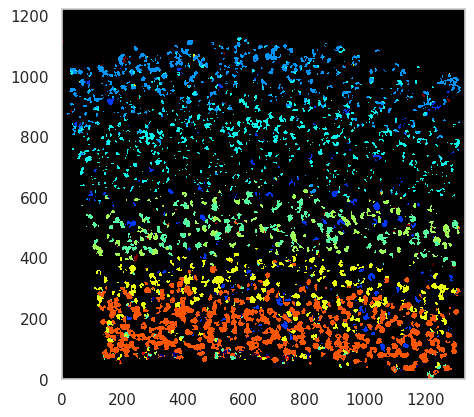

In [ ]:
ds.plot_celltypes_map()

In [ ]:
analysis.filter_celltypemaps(min_r=0.3)

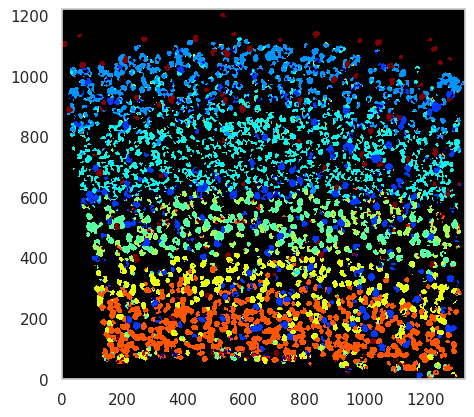

In [ ]:
ds.plot_celltypes_map()

In [ ]:
# Advanced

In [ ]:
from skimage import filters
vfnorm_threshold = filters.threshold_local(ds.vf_norm.compute(), 35)
vfnorm_thresh_im = (ds.vf_norm > vfnorm_threshold).squeeze().compute()

(0.0, 1220.0)

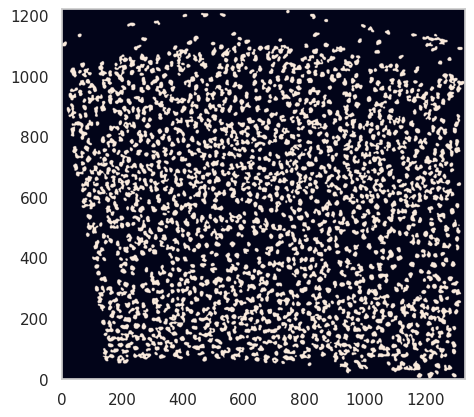

In [ ]:
plt.imshow(vfnorm_thresh_im.swapaxes(0, 1))
plt.ylim([0, vfnorm_thresh_im.shape[1]])

In [ ]:
analysis.run_watershed(vfnorm_thresh_im, spots_xy)

Segmenting cell type #0...
Segmenting cell type #1...
Segmenting cell type #2...
Segmenting cell type #3...
Segmenting cell type #4...
Segmenting cell type #5...
Segmenting cell type #6...
Segmenting cell type #7...
Segmenting cell type #8...
Segmenting cell type #9...
Segmenting cell type #10...
Segmenting cell type #11...
Computing cell by gene matrix...
Computing center of masses...


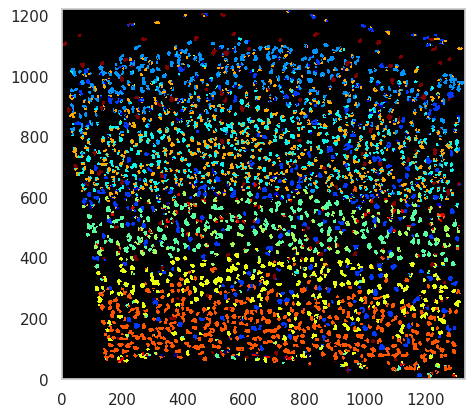

In [ ]:
ds.plot_watershed_celltypes_map()

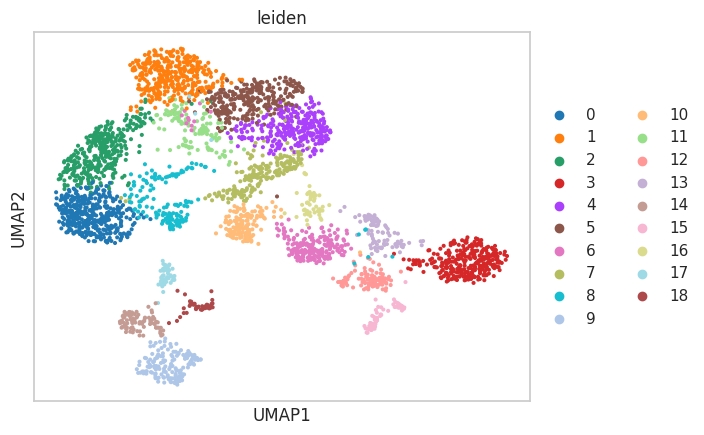

In [ ]:
adata = sc.AnnData(ds.cell_by_gene_matrix)

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.neighbors(adata)

sc.tl.umap(adata)
sc.tl.leiden(adata)
sc.pl.umap(adata, color='leiden')

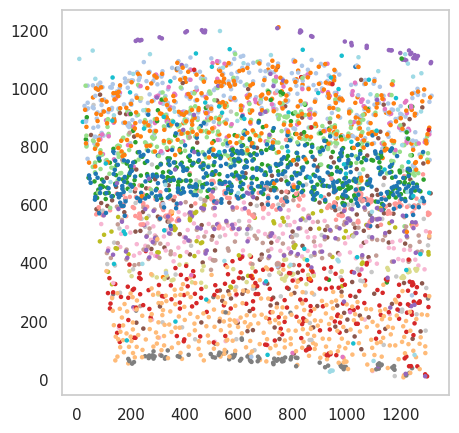

In [ ]:
  plt.figure(figsize=(5, 5))
  plt.scatter(ds.center_of_masses[:, 0], ds.center_of_masses[:, 1],
              c=[int(i) for i in adata.obs['leiden']], cmap='tab20', s=5)